<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_1_4_MLR_Ames_Part4_HyperparameterTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames, Iowa: Hyperparameter Tuning
## Grid Search and the Bias-Variance Tradeoff

Author: Brad Sheese

Part 3 ended with a leaderboard and a confession. Ridge beat OLS by about \$107 per house — but every penalty strength on that leaderboard was a guess ($\alpha = 100$ for Ridge, $0.005$ for Lasso), and we openly suspected that Lasso's last-place finish was the guess's fault, not the model's.

This notebook is where we stop guessing. We'll use **Grid Search** with cross-validation to find optimal hyperparameters systematically, visualize the **Bias-Variance Tradeoff** to understand *why* a particular alpha wins, and find out whether Lasso deserves its redemption.

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocessing & Pipeline tools
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Settings
%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
warnings.filterwarnings('ignore')

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/17_2_MLR/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

data_url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
X_train, X_test, y_train, y_test = load_and_clean_ames(data_url)
print(f"Cleaned X_train shape: {X_train.shape}")
print(f"Cleaned X_test shape: {X_test.shape}")

Cleaned X_train shape: (2340, 225)
Cleaned X_test shape: (585, 225)


### Helper Function

The honest evaluation engine from Part 3, unchanged: pipeline-wrapped cross-validation, metrics reported in real dollars.

In [3]:
def run_evaluation_pipeline(model, X, y, model_name="Model"):
    """
    Standardizes data, runs cross-validation, and returns
    HONEST (Cross-Validated) RMSE/MAE in actual US Dollars.
    """

    # 1. Create the Pipeline
    # This ensures StandardScaler only "sees" the training folds during CV,
    # preventing data leakage.
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    # 2. Calculate Technical CV Log-RMSE
    # This is the standard metric for comparing models in log-space.
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_log = np.sqrt(-cv_scores.mean())

    # 3. Generate "Honest" Predictions (Cross-Val Predict)
    # Instead of predicting on the training data, this generates a prediction
    # for every house using a model that DID NOT see that house during training.
    log_cv_preds = cross_val_predict(pipe, X, y, cv=5)

    # 4. Transform back to Actual US Dollars
    # We must exponentiate both the predictions and the actual target.
    real_cv_preds = np.exp(log_cv_preds)
    real_y_actual = np.exp(y)

    # 5. Calculate Real-World Metrics (Validation Error)
    # These metrics represent your expected error on a new house listing.
    mae_dollars = mean_absolute_error(real_y_actual, real_cv_preds)
    rmse_dollars = np.sqrt(mean_squared_error(real_y_actual, real_cv_preds))

    # 6. Final Fit
    # We fit on the entire provided dataset so the returned pipeline is ready for use.
    pipe.fit(X, y)

    print(f"--- {model_name} (Validation Metrics) ---")
    print(f"CV Log-RMSE:      {cv_rmse_log:.4f}")
    print(f"Real-Dollar MAE:  ${mae_dollars:,.2f}")
    print(f"Real-Dollar RMSE: ${rmse_dollars:,.2f}")
    print("-" * 35)

    return pipe, mae_dollars

## What Exactly Are We Tuning?

A model has two kinds of settings, and the distinction matters. **Parameters** are what the model learns from data — in regression, the coefficients. We never set those by hand; finding them *is* training. **Hyperparameters** are the knobs that must be set *before* training begins, because the model has no way to learn them from the data it sees. For our regularized models, the hyperparameter that matters is **alpha** — the penalty strength.

Why can't the model just learn alpha the way it learns coefficients? Because alpha's whole job is to make the model fit the training data *worse*, on purpose, in exchange for generalizing better. Ask the training data what alpha it prefers and it will always answer "zero, please" — no penalty, maximum fit, maximum overfitting. The right alpha can only be judged on data the model didn't train on. That's why cross-validation is about to do all the heavy lifting.

Choosing alpha is really navigating the **bias-variance tradeoff** we met in 17_1. Set it too low and the model is effectively OLS: it chases every squiggle in the training data, noise included — high variance, overfitting. Set it too high and the penalty crushes real signal along with the noise, flattening the model toward "every house costs about the same" — high bias, underfitting. Somewhere between the ditches is the setting that generalizes best:

| Alpha Setting | Penalty Strength | Model Complexity | Risk |
| :--- | :--- | :--- | :--- |
| **$\alpha \approx 0$** | Almost none | Very complex (OLS) | **Overfitting** (high variance) |
| **Optimal $\alpha$** | Balanced | **"Goldilocks" zone** | **Best generalization** |
| **High $\alpha$** | Very strong | Too simple | **Underfitting** (high bias) |

How do we find that zone when alpha can be any positive number? By brute force, honestly applied: define a **grid** of candidate values (say `[0.01, 0.1, 1, 10, 100]`), train a model at each one, evaluate each with cross-validation, and keep the winner. That's **grid search**, and the rest of the notebook is variations on it.

---

## Seeing the Tradeoff Before Automating It

Before letting the computer search, we should see with our own eyes what it's searching *for*. The loop below manually fits Ridge at several alphas and plots training error against validation error — a **validation curve**. Watch where the two lines part company.

--- Ridge (alpha=0.01) (Validation Metrics) ---
CV Log-RMSE:      0.1223
Real-Dollar MAE:  $13,393.63
Real-Dollar RMSE: $19,853.25
-----------------------------------


--- Ridge (alpha=0.1) (Validation Metrics) ---
CV Log-RMSE:      0.1222
Real-Dollar MAE:  $13,389.63
Real-Dollar RMSE: $19,847.89
-----------------------------------


--- Ridge (alpha=1) (Validation Metrics) ---
CV Log-RMSE:      0.1219
Real-Dollar MAE:  $13,367.23
Real-Dollar RMSE: $19,820.73
-----------------------------------


--- Ridge (alpha=10) (Validation Metrics) ---
CV Log-RMSE:      0.1211
Real-Dollar MAE:  $13,309.33
Real-Dollar RMSE: $19,732.82
-----------------------------------


--- Ridge (alpha=100) (Validation Metrics) ---
CV Log-RMSE:      0.1204
Real-Dollar MAE:  $13,286.88
Real-Dollar RMSE: $19,712.42
-----------------------------------


--- Ridge (alpha=1000) (Validation Metrics) ---
CV Log-RMSE:      0.1271
Real-Dollar MAE:  $14,555.75
Real-Dollar RMSE: $22,147.70
-----------------------------------


--- Ridge (alpha=5000) (Validation Metrics) ---
CV Log-RMSE:      0.1551
Real-Dollar MAE:  $19,151.75
Real-Dollar RMSE: $30,823.72
-----------------------------------


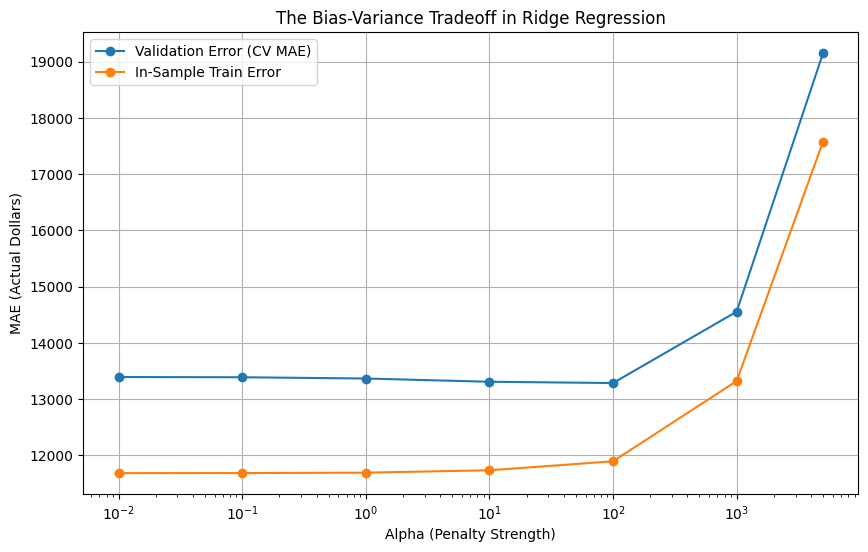

In [4]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 5000]
cv_mae_results = []
train_mae_results = []

for a in alphas:
    # 1. Setup the model with current alpha
    model = Ridge(alpha=a)

    # 2. Use our pipeline to get the 'Honest' Validation MAE
    pipe, cv_mae = run_evaluation_pipeline(model, X_train, y_train, model_name=f"Ridge (alpha={a})")
    cv_mae_results.append(cv_mae)

    # 3. Calculate In-Sample Train MAE (for comparison)
    # run_evaluation_pipeline fits pipe on all of X_train as its final step,
    # so pipe.predict(X_train) is predicting on the exact data the model trained on.
    # This is not a CV training-fold score — it is pure memorization, and will
    # always look artificially good (especially at low alpha where the model overfits).
    train_preds = np.exp(pipe.predict(X_train))
    train_mae = mean_absolute_error(np.exp(y_train), train_preds)
    train_mae_results.append(train_mae)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_mae_results, label='Validation Error (CV MAE)', marker='o')
plt.plot(alphas, train_mae_results, label='In-Sample Train Error', marker='o')
plt.xscale('log') # Use log scale because alphas vary by orders of magnitude
plt.xlabel('Alpha (Penalty Strength)')
plt.ylabel('MAE (Actual Dollars)')
plt.title('The Bias-Variance Tradeoff in Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

**How to read this plot:**

On the **left** (low alpha), training error is at its lowest while validation error is high — the overfitting zone, where the model is busy memorizing houses it will never see again. On the **right** (high alpha), both errors rise together — the underfitting zone, where the penalty is crushing real signal. The bottom of the **validation curve** is the Goldilocks zone: the alpha that will serve us best on future house sales. Everything that follows is just finding that minimum precisely.

---

The manual loop was worth it for the picture, but it doesn't scale: checking 1,000 alphas — or tuning two hyperparameters at once, which is coming — would turn it into a nightmare of nested loops. `GridSearchCV` automates exactly this process: the looping, the cross-validation, and the bookkeeping of which setting won.

## Automating the Search with GridSearchCV

`GridSearchCV` does three things: takes a dictionary of hyperparameter candidates and tests every combination, evaluates each with cross-validation (the same honest procedure as our manual loop), and refits the winning configuration on the full training set so it's ready to use.

**One syntax rule worth memorizing — the double underscore.** Our model lives inside a Pipeline (that's what keeps the scaler honest during CV), so `GridSearchCV` can't see `alpha` directly. The address format is *step name, two underscores, parameter name*: `regressor__alpha`. You will use this pattern in every pipeline-based grid search you ever run.

### Tuning Ridge

Let's see if the machine can beat our manual guess of $\alpha = 100$. We hand it a grid spanning 0.01 to 10,000 — generated with `np.logspace`, which spaces values by powers of ten, the natural scale for searching penalty strengths.

In [5]:
from sklearn.model_selection import GridSearchCV

# 1. Set up the base pipeline
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

# 2. Define the Hyperparameter Grid
# np.logspace(-2, 4, 100) creates 100 values between 0.01 and 10,000
param_grid_ridge = {
    'regressor__alpha': np.logspace(-2, 4, 100)
}

# 3. Initialize GridSearchCV
# We use negative MSE because scikit-learn's optimizers always try to MAXIMIZE the score.
# Maximizing a negative error is the same as minimizing a positive error.
ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    refit=True,  # After finding the best alpha, automatically refit on all training data
    n_jobs=-1    # Uses all available CPU cores to speed up the search
)

# 4. Run the Search
print("Searching for optimal Ridge Alpha...")
ridge_grid.fit(X_train, y_train)

# 5. Extract the Results
best_ridge_alpha = ridge_grid.best_params_['regressor__alpha']
print(f"Optimal Ridge Alpha found: {best_ridge_alpha:.2f}")

Searching for optimal Ridge Alpha...


Optimal Ridge Alpha found: 86.97


The finished `ridge_grid` now *is* our best Ridge model — grid search refit it on the full training set automatically. Let's get its real-dollar validation MAE from our honest evaluation function.

In [6]:
# Evaluate the tuned Ridge model using our honest CV function
# We extract the optimized model from the grid search to test it
tuned_ridge = Ridge(alpha=best_ridge_alpha)
_, tuned_ridge_mae = run_evaluation_pipeline(tuned_ridge, X_train, y_train, "Tuned Ridge")

--- Tuned Ridge (Validation Metrics) ---
CV Log-RMSE:      0.1204
Real-Dollar MAE:  $13,276.77
Real-Dollar RMSE: $19,692.90
-----------------------------------


---

## Lasso: The Redemption Arc

In Part 3, Lasso finished dead last (\$13,712 MAE) — and we entered a plea of not guilty on its behalf. The guessed $\alpha = 0.005$ made it delete 159 of 225 features, and we suspected it was throwing away real signal.

One subtlety before the retrial: Lasso's alpha scale is far more sensitive than Ridge's, because every increment of penalty doesn't just shrink coefficients — it *deletes features outright*. So we search a much tighter, smaller range of alphas than we did for Ridge.

In [7]:
# 1. Set up the base pipeline
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Lasso(max_iter=10000)) # Increased max_iter for convergence
])

# 2. Define the Grid for Lasso (Notice the smaller scale: 0.0001 to 0.1)
param_grid_lasso = {
    'regressor__alpha': np.logspace(-4, -1, 50)
}

# 3. Initialize and Fit GridSearchCV
lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Searching for optimal Lasso Alpha...")
lasso_grid.fit(X_train, y_train)

best_lasso_alpha = lasso_grid.best_params_['regressor__alpha']
print(f"Optimal Lasso Alpha found: {best_lasso_alpha:.5f}")

# 4. Evaluate the Tuned Lasso Model
tuned_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
_, tuned_lasso_mae = run_evaluation_pipeline(tuned_lasso, X_train, y_train, "Tuned Lasso")

Searching for optimal Lasso Alpha...


Optimal Lasso Alpha found: 0.00193


--- Tuned Lasso (Validation Metrics) ---
CV Log-RMSE:      0.1184
Real-Dollar MAE:  $13,217.55
Real-Dollar RMSE: $19,675.92
-----------------------------------


---

### Reading the Verdict

Two things to look for in the tuned results:

**The comeback.** If the optimal alpha lands well below our 0.005 guess, it confirms the diagnosis — our guess was crushing important variables. Properly tuned, Lasso should now be competitive with Ridge, possibly ahead of it.

**The feature count.** The other question is what a *well-tuned* Lasso thinks the right model size is. Let's see how many of the 225 features it kept this time:

In [8]:
# Extract the best Lasso model from the grid
best_lasso_model = lasso_grid.best_estimator_.named_steps['regressor']
non_zero_features = np.sum(best_lasso_model.coef_ != 0)

print(f"Original Features: {X_train.shape[1]}")
print(f"Features kept by Tuned Lasso: {non_zero_features}")
print(f"Features deleted: {X_train.shape[1] - non_zero_features}")

Original Features: 225
Features kept by Tuned Lasso: 116
Features deleted: 109


---

## The ROI of Hyperparameter Tuning

Tuning costs compute and effort, so it's fair to ask what it bought us. The cleanest answer: line up the "guessed" models from Part 3 against their tuned versions and compare dollar MAEs.

In [9]:
# re-run the untunded versions
ridge_model = Ridge(alpha=100)
ridge_pipe, ridge_mae = run_evaluation_pipeline(ridge_model, X_train, y_train, "Ridge (L2)")

lasso_model = Lasso(alpha=0.005)
lasso_pipe, lasso_mae = run_evaluation_pipeline(lasso_model, X_train, y_train, "Lasso (L1)")


# 1. Compile the results into a DataFrame
# (Using the MAE variables generated from our evaluation functions)
comparison_data = {
    'Model':['Ridge (L2)', 'Lasso (L1)'],
    'Untuned MAE':[ridge_mae, lasso_mae],      # From Part 3 (our "guesses")
    'Tuned MAE':[tuned_ridge_mae, tuned_lasso_mae] # From Part 4 (GridSearchCV)
}

comparison_df = pd.DataFrame(comparison_data)

# 2. Calculate the direct dollar improvement
comparison_df['Improvement ($)'] = comparison_df['Untuned MAE'] - comparison_df['Tuned MAE']

print("--- Final Model Performance Comparison ---")
# Using .applymap to format as currency for clean reading
display(comparison_df.style.format({
    'Untuned MAE': '${:,.2f}',
    'Tuned MAE': '${:,.2f}',
    'Improvement ($)': '${:,.2f}'
}))

--- Ridge (L2) (Validation Metrics) ---
CV Log-RMSE:      0.1204
Real-Dollar MAE:  $13,286.88
Real-Dollar RMSE: $19,712.42
-----------------------------------


--- Lasso (L1) (Validation Metrics) ---
CV Log-RMSE:      0.1206
Real-Dollar MAE:  $13,712.45
Real-Dollar RMSE: $20,392.10
-----------------------------------
--- Final Model Performance Comparison ---


,Model,Untuned MAE,Tuned MAE,Improvement ($)
0,Ridge (L2),"$13,286.88","$13,276.77",$10.10
1,Lasso (L1),"$13,712.45","$13,217.55",$494.90


To make the impact legible to a stakeholder at a glance, the same comparison as a plot:

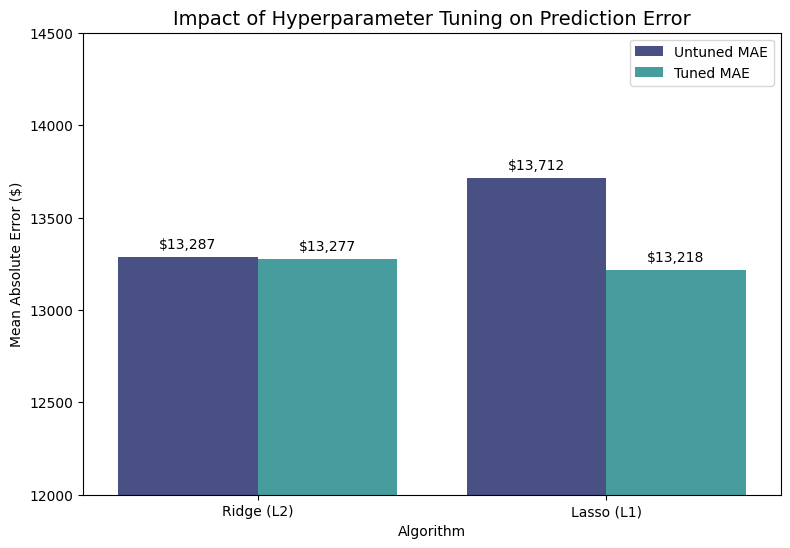

In [10]:
# Melt the DataFrame so it is formatted perfectly for Seaborn
melted_df = comparison_df.melt(
    id_vars='Model',
    value_vars=['Untuned MAE', 'Tuned MAE'],
    var_name='Tuning Status',
    value_name='MAE (Dollars)'
)

# Plot the grouped bar chart
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=melted_df, x='Model', y='MAE (Dollars)', hue='Tuning Status', palette='mako')

# Formatting the plot
plt.title('Impact of Hyperparameter Tuning on Prediction Error', fontsize=14)
plt.ylabel('Mean Absolute Error ($)')
plt.xlabel('Algorithm')

# Zoom in on the relevant error range (approx 12k to 14k) to make the difference visible
# (You may need to adjust these limits slightly based on your exact random seed output)
plt.ylim(12000, 14500)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.legend(title='')
plt.show()

### What the Comparison Shows

**Ridge barely moved.** Tuning nudged it only incrementally — which is itself a finding. Ridge is robust to a mediocre alpha; its smooth shrinkage degrades gracefully. If you must ship a model with minimal tuning budget, this is a point in Ridge's favor.

**Lasso transformed.** The model we wrote off in Part 3 leapt from last place to the most accurate in the analysis, purely by changing one number. Nothing about the algorithm changed — only the penalty strength. The lesson generalizes: *an untuned model's leaderboard position tells you almost nothing about the algorithm's ceiling.*

Together: cross-validation kept the evaluation honest, grid search found the optimum, and the combination turned a defensible model into a professional-grade one.

We've now completed the standard optimization loop — baseline (OLS overfit), guess (regularization helped, guessing held it back), optimize (grid search found the Goldilocks zone). One model from Part 3 is still waiting for its proper tuning, and it's the expensive one: Elastic Net, with *two* dials.

---
## Tuning Elastic Net: The Two-Dimensional Search

Ridge asked for one number. Lasso asked for one number. Elastic Net, as the hybrid, asks for two at once: **`alpha`** (total penalty strength) and **`l1_ratio`** (the Lasso/Ridge blend, from 0.0 = pure Ridge to 1.0 = pure Lasso).

Tuning two dials means searching a *grid* in the literal sense. Testing 50 alphas × 10 ratios is 500 combinations; multiply by 5-fold cross-validation and the computer fits **2,500 models**. This is the "two-dimensional search" cost we flagged back in Part 3's reflection, now arriving as an actual seven-minute wait — and why `n_jobs=-1` (use every CPU core) earns its keep.

In [11]:
#NOTE: This takes about 7 minutes to run

# 1. Set up the base pipeline
en_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', ElasticNet(max_iter=10000))
])

# 2. Define the 2D Hyperparameter Grid
# We provide a spread of l1_ratios to let the computer decide the best blend.
# We include 0.01 (mostly Ridge) up to 0.99 (mostly Lasso).
param_grid_en = {
    'regressor__alpha': np.logspace(-4, 2, 50),
    'regressor__l1_ratio':[0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
}

# 3. Initialize GridSearchCV
en_grid = GridSearchCV(
    estimator=en_pipe,
    param_grid=param_grid_en,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Run the Search (This may take a moment!)
print("Searching for optimal Elastic Net parameters...")
en_grid.fit(X_train, y_train)

# 5. Extract the Results
best_en_alpha = en_grid.best_params_['regressor__alpha']
best_en_ratio = en_grid.best_params_['regressor__l1_ratio']

print(f"Optimal Alpha found:    {best_en_alpha:.5f}")
print(f"Optimal L1-Ratio found: {best_en_ratio}")

Searching for optimal Elastic Net parameters...


Optimal Alpha found:    0.01600
Optimal L1-Ratio found: 0.1


### Evaluating the Tuned Elastic Net

With both dials set at their mathematical optimum, we pass the model through the same honest validation function as the others.

In [12]:
# 6. Evaluate the Tuned Elastic Net Model
tuned_en = ElasticNet(alpha=best_en_alpha, l1_ratio=best_en_ratio, max_iter=10000)
_, tuned_en_mae = run_evaluation_pipeline(tuned_en, X_train, y_train, "Tuned Elastic Net")

--- Tuned Elastic Net (Validation Metrics) ---
CV Log-RMSE:      0.1184
Real-Dollar MAE:  $13,183.75
Real-Dollar RMSE: $19,628.30
-----------------------------------


---

### What the Chosen Blend Tells Us

The most informative output of a tuned Elastic Net isn't its MAE — it's the **`l1_ratio`** the search settled on, because that number is the dataset describing itself. A high ratio (0.9+) says "this data wants Lasso": most features are dead weight worth deleting. A low ratio (0.1 or less) says "this data wants Ridge": the signal is spread across many features that should be kept and shrunk. A middle value says the data genuinely benefits from the hybrid — grouped shrinkage for the correlated features, deletion for the pure noise.

Let's add the tuned Elastic Net to the final leaderboard and see both its score and its chosen blend.

In [13]:
# rerun old untuned elasticnet
en_model = ElasticNet(alpha=0.01, l1_ratio=0.5)
en_pipe, en_mae = run_evaluation_pipeline(en_model, X_train, y_train, "Elastic Net")


# Add Elastic Net to our previous dictionary and recreate the dataframe
final_comparison_data = {
    'Model':['Ridge (L2)', 'Lasso (L1)', 'Elastic Net (Hybrid)'],
    'Untuned MAE':[ridge_mae, lasso_mae, en_mae],
    'Tuned MAE':[tuned_ridge_mae, tuned_lasso_mae, tuned_en_mae]
}

final_comparison_df = pd.DataFrame(final_comparison_data)
final_comparison_df['Improvement ($)'] = final_comparison_df['Untuned MAE'] - final_comparison_df['Tuned MAE']

print("--- The Final Ames Housing Leaderboard ---")
display(final_comparison_df.style.format({
    'Untuned MAE': '${:,.2f}',
    'Tuned MAE': '${:,.2f}',
    'Improvement ($)': '${:,.2f}'
}))

--- Elastic Net (Validation Metrics) ---
CV Log-RMSE:      0.1205
Real-Dollar MAE:  $13,716.00
Real-Dollar RMSE: $20,402.25
-----------------------------------
--- The Final Ames Housing Leaderboard ---


,Model,Untuned MAE,Tuned MAE,Improvement ($)
0,Ridge (L2),"$13,286.88","$13,276.77",$10.10
1,Lasso (L1),"$13,712.45","$13,217.55",$494.90
2,Elastic Net (Hybrid),"$13,716.00","$13,183.75",$532.25


### Final Thoughts on Elastic Net

The search chose `l1_ratio = 0.1` — mostly Ridge with a touch of Lasso — and landed within a few dozen dollars of Tuned Lasso. This convergence is typical: once properly tuned, the regularized models tend toward nearly identical performance on this dataset, whichever blend they start from.

When that happens in practice, **Occam's Razor** applies: if the two-dial model performs essentially the same as a one-dial model, ship the one-dial model. It's faster to tune, simpler to maintain, and easier to explain to a stakeholder. Elastic Net earns its keep only when its extra dimension buys a real, measurable improvement — here, it didn't.

---

## The Final Exam: The Unseen Test Set

Every number so far — including the cross-validated MAEs — came from `X_train`. And we have been *querying* that training data heavily: hundreds of grid-search fits, each one asking "which alpha do you like?" There's a small but real risk that our hyperparameters are now slightly overfit to the training set's particular quirks.

This is the moment the test set has been waiting for. `X_test` has been locked in a vault since the first cell of this series — no model, scaler, or grid search has ever touched it. Predicting it is the closest thing we have to predicting genuinely future house sales.

First, a small function to fit each tuned model on the full training set and score it on the test set in dollars.

In [14]:
def evaluate_on_test(model, X_train, y_train, X_test, y_test, model_name):
    """
    Fits the tuned model on the full training data,
    predicts on the unseen test data, and returns actual Dollar MAE.
    """
    # 1. Build the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    # 2. Fit on the ENTIRE training set (using the optimized hyperparameters)
    pipe.fit(X_train, y_train)

    # 3. Predict on the completely unseen Test Set
    log_test_preds = pipe.predict(X_test)

    # 4. Convert back to Real Dollars
    real_test_preds = np.exp(log_test_preds)
    real_test_y = np.exp(y_test)

    # 5. Calculate Test MAE
    test_mae = mean_absolute_error(real_test_y, real_test_preds)

    return test_mae

Now the final evaluation: the OLS baseline against our fully tuned, optimally regularized models.

In [15]:
# Compute OLS cross-validated MAE on training data for the baseline comparison below
_, ols_cv_mae = run_evaluation_pipeline(LinearRegression(), X_train, y_train, "OLS Baseline")

--- OLS Baseline (Validation Metrics) ---
CV Log-RMSE:      0.1223
Real-Dollar MAE:  $13,394.12
Real-Dollar RMSE: $19,853.92
-----------------------------------


In [16]:
# Evaluate all models on the Test Set
test_mae_ols = evaluate_on_test(LinearRegression(), X_train, y_train, X_test, y_test, "OLS")
test_mae_ridge = evaluate_on_test(tuned_ridge, X_train, y_train, X_test, y_test, "Tuned Ridge")
test_mae_lasso = evaluate_on_test(tuned_lasso, X_train, y_train, X_test, y_test, "Tuned Lasso")
test_mae_en = evaluate_on_test(tuned_en, X_train, y_train, X_test, y_test, "Tuned Elastic Net")

# Create a final results dataframe
final_test_results = pd.DataFrame({
    'Model':['OLS Baseline', 'Tuned Ridge', 'Tuned Lasso', 'Tuned Elastic Net'],
    'CV Validation MAE (Train Data)':[ols_cv_mae, tuned_ridge_mae, tuned_lasso_mae, tuned_en_mae],
    'Unseen Test MAE (Test Data)':[test_mae_ols, test_mae_ridge, test_mae_lasso, test_mae_en]
})

# Calculate the difference to see if we overfit during tuning
final_test_results['Performance Drop'] = final_test_results['Unseen Test MAE (Test Data)'] - final_test_results['CV Validation MAE (Train Data)']

# Display formatted results
display(final_test_results.style.format({
    'CV Validation MAE (Train Data)': '${:,.2f}',
    'Unseen Test MAE (Test Data)': '${:,.2f}',
    'Performance Drop': '${:,.2f}'
}))

,Model,CV Validation MAE (Train Data),Unseen Test MAE (Test Data),Performance Drop
0,OLS Baseline,"$13,394.12","$11,723.77","$-1,670.35"
1,Tuned Ridge,"$13,276.77","$11,786.86","$-1,489.92"
2,Tuned Lasso,"$13,217.55","$11,590.92","$-1,626.63"
3,Tuned Elastic Net,"$13,183.75","$11,611.82","$-1,571.93"


### Interpreting the Final Test Results

When looking at the final dataframe, keep these principles in mind:

1.  **Who Won?** Look strictly at the **Unseen Test MAE**. The model with the lowest error here is the one you would deploy to production or hand over to a real estate client.
2.  **The Overfitting Check:** Look at the **Performance Drop** column.
    * A small positive drop (Test MAE slightly worse than CV MAE, say \$500–\$1,500) is expected and healthy — the model is generalizing well.
    * A large drop (e.g., \$5,000+) would indicate the model still suffers from high variance and the hyperparameter tuning overfit the training data.
    * A **negative** drop — which is what we actually see here (test MAE about \$1,500 *better* than the CV estimate) — means this particular 20% test split happens to contain easier-to-predict houses than the CV average. Part 2 saw the same favorable draw. The sign of a small drop varies from split to split; what matters is that its magnitude is modest.
3.  **The "So What?" (ROI):** You can now state: *"By switching from OLS to a mathematically tuned regularized model, we reduced our real-world prediction error on unseen houses."*

---

## Conclusion

We set out to stop guessing at alpha values. We succeeded:

*   **GridSearchCV** gave us a principled, automated way to search across 100 penalty strengths and find the mathematical optimum.
*   **Pipelines inside GridSearchCV** ensured StandardScaler never peeked at validation folds during the search.
*   **Test set evaluation** confirmed the tuned models generalize: the performance drops are modest, and Tuned Lasso wins.

---

## Looking Ahead: Is Our Test Score Trustworthy?

There is a subtle problem hidden in this notebook. To produce the comparison table above, we:

1. Tuned Ridge's alpha using cross-validation on `X_train`.
2. Tuned Lasso's alpha using cross-validation on `X_train`.
3. Tuned Elastic Net's alpha and `l1_ratio` using cross-validation on `X_train`.
4. Picked the winner by comparing all three against the same test set.

Every time you consult the test set to make a decision — even the decision of *which model to report* — a small amount of information from that test set leaks into your choices. The more models you compare against the same test set, the more optimistic the winning score becomes.

**Part 5 tackles this directly.** Nested Cross-Validation eliminates the locked-away test set entirely and replaces it with two layers of cross-validation that keep hyperparameter tuning and performance evaluation fully independent. The result is a performance estimate you can report without any asterisks.